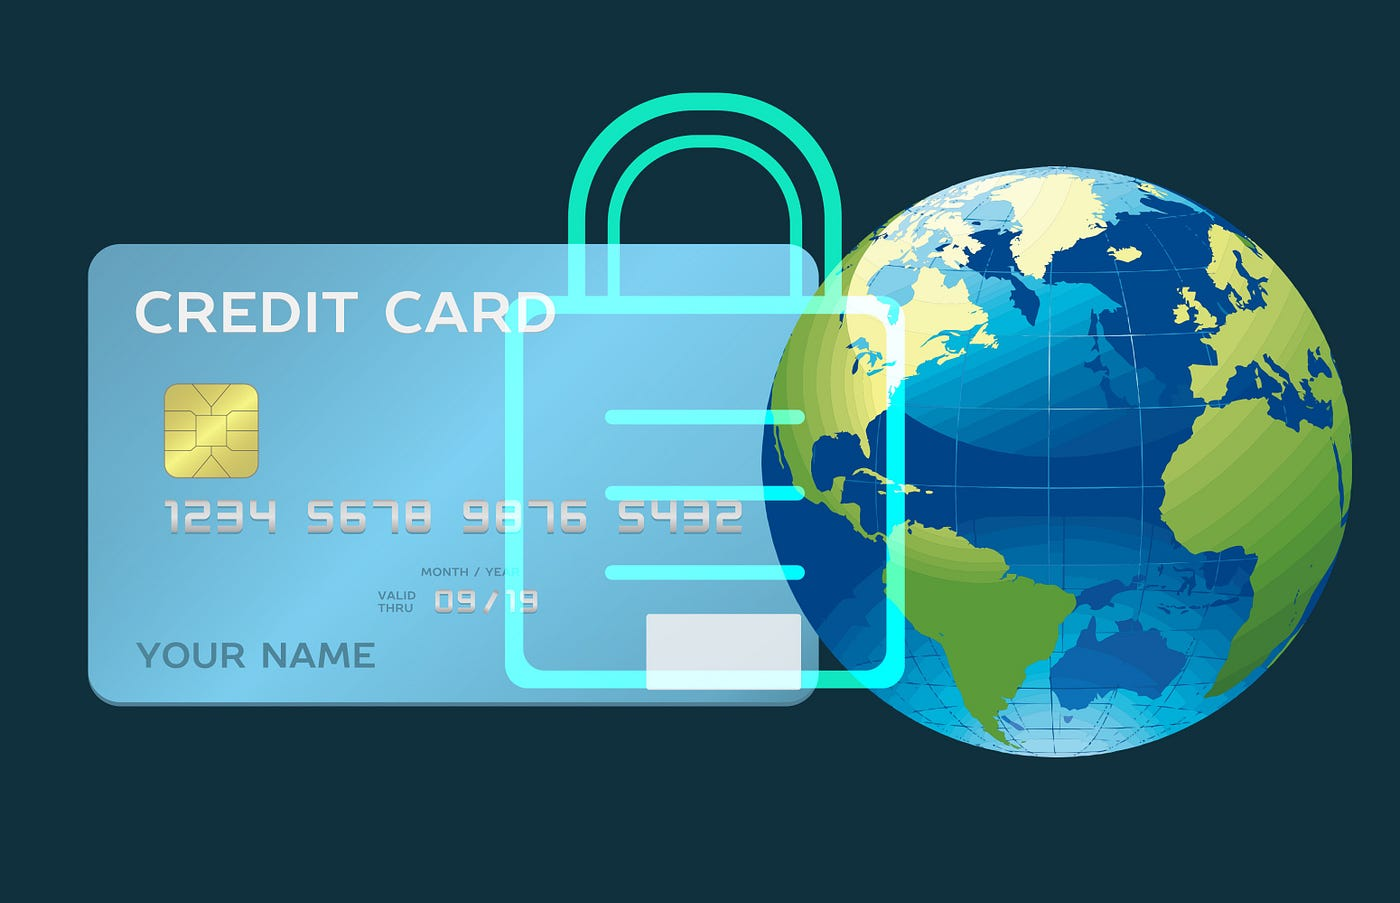

# 💳 Credit Card Fraud Detection — Complete End-to-End Project

This notebook walks through a **full data science project** on a simulated credit card
transactions dataset, from raw data all the way to a working fraud-detection model.

**What you will learn / do in this notebook:**
1. Load and inspect the data
2. Clean and prepare it for analysis
3. Explore it visually (EDA) to find patterns
4. Engineer useful features
5. Use clustering to spot unusual groups of transactions
6. Build and compare 3 machine learning models (Logistic Regression, Decision Tree, Random Forest)
7. Evaluate the models properly (accuracy alone is **not enough** for fraud data!)
8. Draw conclusions and suggest next steps

> 💡 **How to use this notebook:** Run the cells **from top to bottom**, one at a time
> (click a cell and press `Shift + Enter`). Every section has plain-English explanations
> before the code, so you don't need to be an expert to follow along.


#Overview
Credit card fraud represents a significant threat to the integrity of financial transactions and consumer trust in digital commerce. As the reliance on credit cards for everyday purchases continues to grow, so does the sophistication of fraudsters exploiting vulnerabilities in the system. This project aims to analyze patterns of credit card fraud, understand the factors contributing to fraudulent activities, and explore effective methods for detection and prevention.

#Dataset Description
The dataset comprises 100,000 transactions generated to simulate real-world credit card activity. Each entry includes the following features:


-TransactionID: A unique identifier for each transaction, ensuring traceability.

-TransactionDate: The date and time when the transaction occurred, allowing for temporal analysis.

-Amount: The monetary value of the transaction, which can help identify unusually large transactions that may indicate fraud.

-MerchantID: An identifier for the merchant involved in the transaction, useful for assessing merchant-related fraud patterns.

-TransactionType: Indicates whether the transaction was a purchase or a refund, providing context for the activity.

-Location: The geographic location of the transaction, facilitating analysis of fraud trends by region.

-IsFraud: A binary target variable indicating whether the transaction is fraudulent (1) or legitimate (0), essential for supervised learning models.

## 1. Setup — Install & Import Libraries

We start by importing all the Python libraries we'll need. All of these come
pre-installed on Google Colab, so this cell should run without any errors.


In [7]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Make our charts look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Make results reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 2. Load the Dataset

The dataset (`credit_card_fraud_dataset.csv`) has **100,000 transactions** with these columns:

| Column | Meaning |
|---|---|
| `TransactionID` | Unique ID for each transaction |
| `TransactionDate` | Date & time of the transaction |
| `Amount` | Transaction amount in currency units |
| `MerchantID` | ID of the merchant |
| `TransactionType` | `purchase` or `refund` |
| `Location` | City where the transaction happened |
| `IsFraud` | Target: `1` = fraud, `0` = legitimate |

### 📤 Upload the file in Colab
Run the cell below. It will pop up an **"Choose Files"** button — click it and select
`credit_card_fraud_dataset.csv` from your computer.

*(If you're running this outside Colab, e.g. locally or on Kaggle, the code will
automatically skip the upload step and simply look for the CSV file in the current folder — just place it there first.)*


In [8]:
df = pd.read_csv('/content/credit_card_fraud_dataset.csv')
print(f"✅ Loaded '{df}' successfully!")
print(f"Shape of the dataset: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()


✅ Loaded '       TransactionID             TransactionDate   Amount  MerchantID  \
0                  1  2024-04-03 14:15:35.462794  4189.27         688   
1                  2  2024-03-19 13:20:35.462824  2659.71         109   
2                  3  2024-01-08 10:08:35.462834   784.00         394   
3                  4  2024-04-13 23:50:35.462850  3514.40         944   
4                  5  2024-07-12 18:51:35.462858   369.07         475   
...              ...                         ...      ...         ...   
99995          99996  2024-06-07 00:57:36.027591  1057.29         289   
99996          99997  2023-10-22 23:12:36.027594   297.25         745   
99997          99998  2024-05-31 19:27:36.027597  3448.56         690   
99998          99999  2024-10-18 09:43:36.027601  3750.79         644   
99999         100000  2024-03-05 19:41:36.027606  1596.79         675   

      TransactionType      Location  IsFraud  
0              refund   San Antonio        0  
1              refu

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


## 3. First Look at the Data

Before doing anything fancy, let's understand what we're working with:
data types, missing values, and basic statistics.


In [9]:
# Basic info: column names, data types, non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [10]:
# Check for missing values in every column
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64


In [11]:
# Summary statistics for numeric columns
df.describe()


,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [12]:
# Convert TransactionDate to a proper datetime type
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

# Quick sanity check on the date range
print("Earliest transaction:", df['TransactionDate'].min())
print("Latest transaction:  ", df['TransactionDate'].max())


Earliest transaction: 2023-10-21 09:28:35.824439
Latest transaction:   2024-10-21 09:20:35.961088


## 4. How Balanced Is Fraud vs. Legitimate? (Very Important!)

Fraud is, thankfully, rare in real life and that's reflected here too.
This is called **class imbalance**, and it's the single most important thing
to understand before building any fraud model. If we ignore it, a lazy model
could get 99% "accuracy" just by predicting "not fraud" every single time —
while catching **zero** actual fraud!


Transaction counts:
IsFraud
0    99000
1     1000
Name: count, dtype: int64

Percentage breakdown:
IsFraud
0    99.0
1     1.0
Name: proportion, dtype: float64


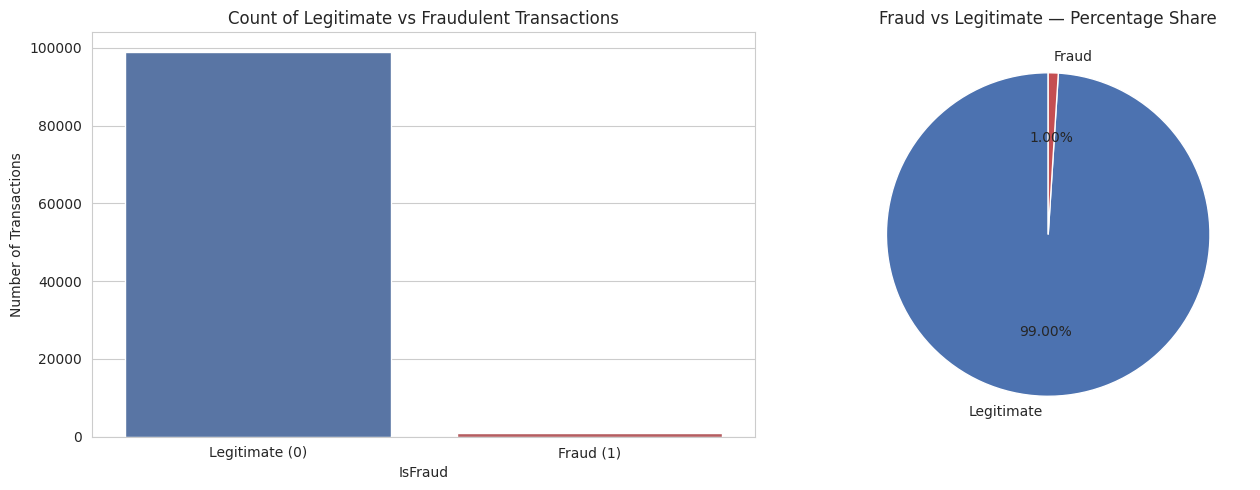


⚠️ Only 1.00% of transactions are fraudulent.
This confirms a HIGHLY IMBALANCED dataset — we'll need special care when modeling and evaluating.


In [13]:
fraud_counts = df['IsFraud'].value_counts()
fraud_pct = df['IsFraud'].value_counts(normalize=True) * 100

print("Transaction counts:")
print(fraud_counts)
print("\nPercentage breakdown:")
print(fraud_pct.round(2))

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='IsFraud', data=df, hue='IsFraud', palette=['#4C72B0', '#C44E52'],
              legend=False, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax[0].set_title('Count of Legitimate vs Fraudulent Transactions')
ax[0].set_ylabel('Number of Transactions')

ax[1].pie(fraud_counts, labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
          colors=['#4C72B0', '#C44E52'], startangle=90)
ax[1].set_title('Fraud vs Legitimate — Percentage Share')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Only {fraud_pct[1]:.2f}% of transactions are fraudulent.")
print("This confirms a HIGHLY IMBALANCED dataset — we'll need special care when modeling and evaluating.")


## 5. Exploratory Data Analysis (EDA)

### 5.1 Distribution of Transaction Amounts
Let's see how transaction amounts are spread out, and whether fraudulent
transactions tend to have different amounts than legitimate ones.


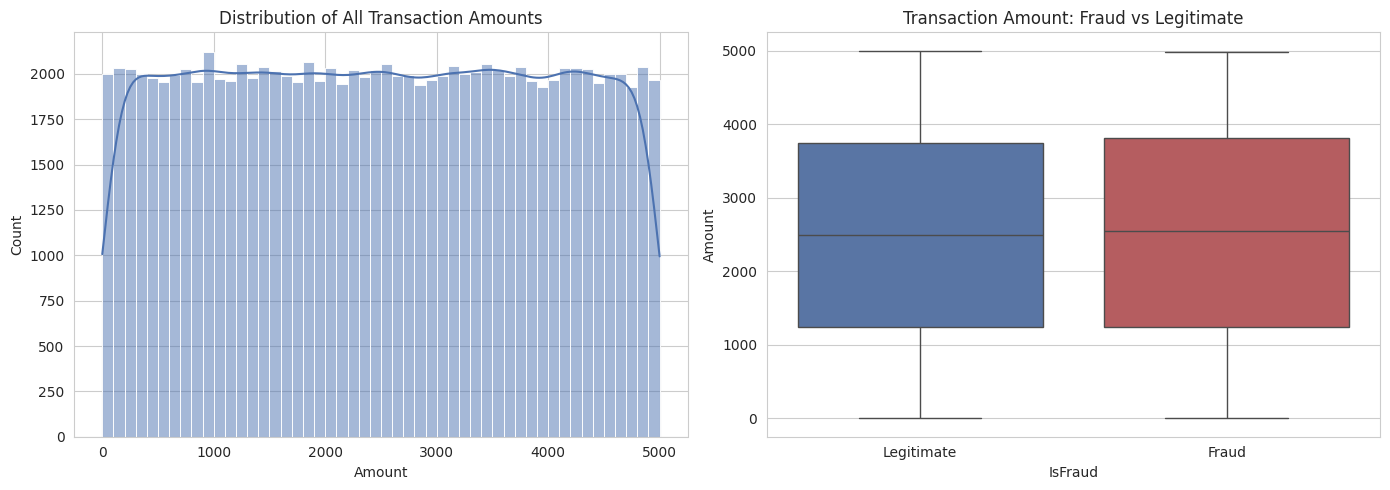

Average amount - Legitimate: 2496.89
Average amount - Fraud:      2517.16


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Amount'], bins=50, kde=True, ax=ax[0], color='#4C72B0')
ax[0].set_title('Distribution of All Transaction Amounts')
ax[0].set_xlabel('Amount')

sns.boxplot(x='IsFraud', y='Amount', data=df, hue='IsFraud', palette=['#4C72B0', '#C44E52'],
            legend=False, ax=ax[1])
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Legitimate', 'Fraud'])
ax[1].set_title('Transaction Amount: Fraud vs Legitimate')

plt.tight_layout()
plt.show()

print("Average amount - Legitimate:", round(df[df['IsFraud']==0]['Amount'].mean(), 2))
print("Average amount - Fraud:     ", round(df[df['IsFraud']==1]['Amount'].mean(), 2))


### 5.2 Transaction Type: Purchase vs Refund
Does fraud happen more often in purchases or refunds?


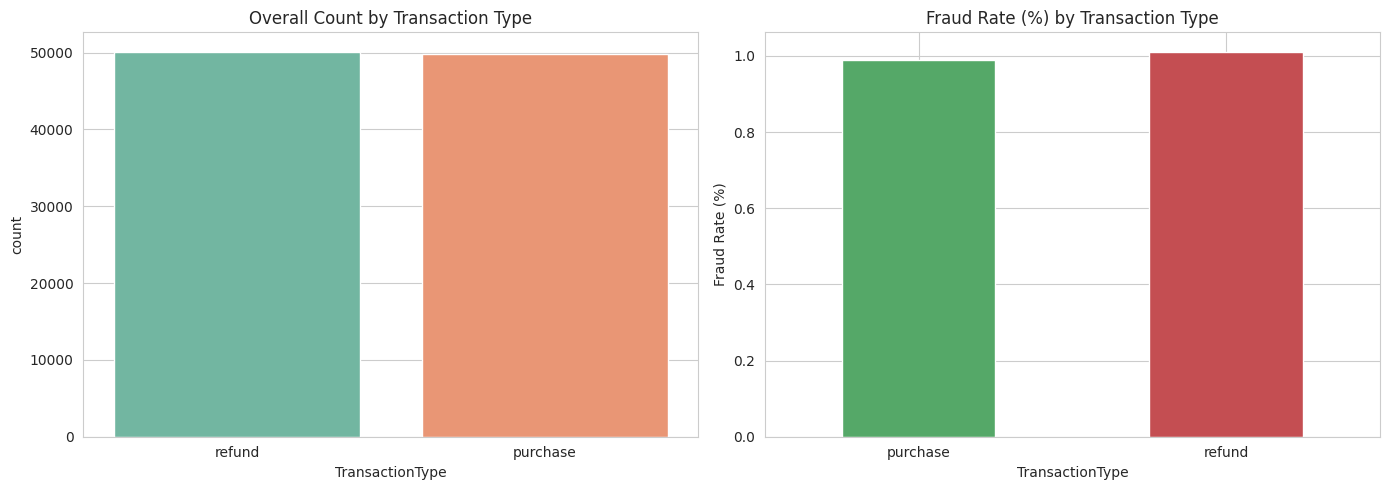

TransactionType
purchase    0.989
refund      1.011
Name: IsFraud, dtype: float64


In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='TransactionType', data=df, hue='TransactionType', palette='Set2',
              legend=False, ax=ax[0])
ax[0].set_title('Overall Count by Transaction Type')

# Fraud rate (%) within each transaction type
fraud_rate_by_type = df.groupby('TransactionType')['IsFraud'].mean() * 100
fraud_rate_by_type.plot(kind='bar', color=['#55A868', '#C44E52'], ax=ax[1])
ax[1].set_title('Fraud Rate (%) by Transaction Type')
ax[1].set_ylabel('Fraud Rate (%)')
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(fraud_rate_by_type.round(3))


### 5.3 Fraud by Location
Are some cities more prone to fraud than others?


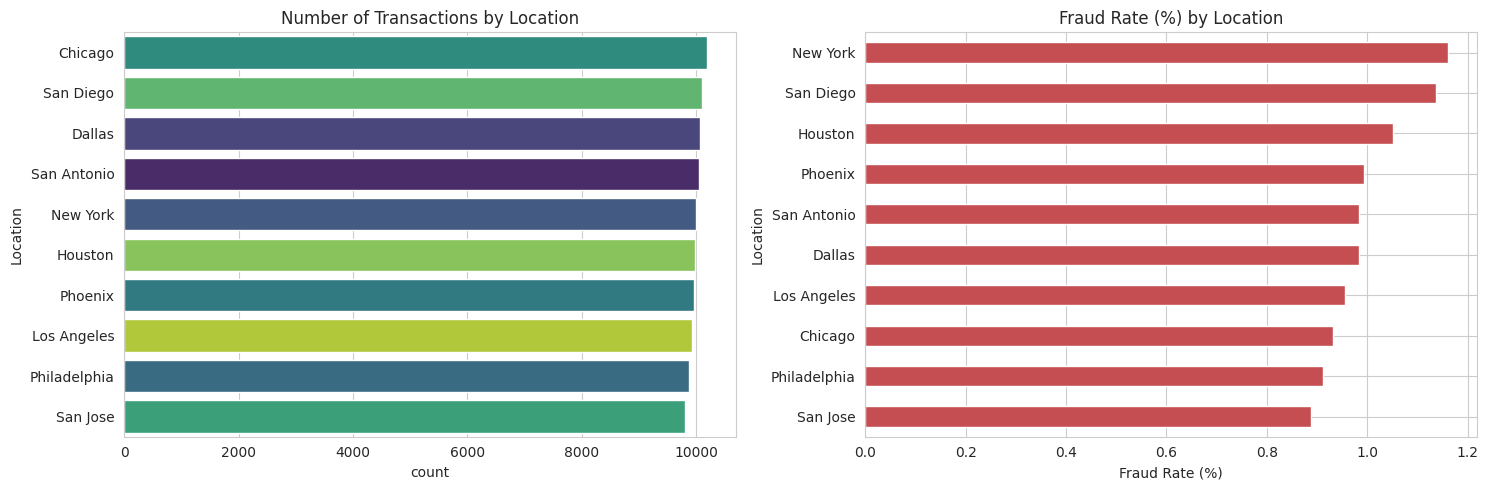

Location
New York        1.161
San Diego       1.137
Houston         1.051
Phoenix         0.994
San Antonio     0.984
Dallas          0.983
Los Angeles     0.956
Chicago         0.932
Philadelphia    0.912
San Jose        0.887
Name: IsFraud, dtype: float64


In [16]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(y='Location', data=df, order=df['Location'].value_counts().index,
              hue='Location', palette='viridis', legend=False, ax=ax[0])
ax[0].set_title('Number of Transactions by Location')

fraud_rate_by_location = (df.groupby('Location')['IsFraud'].mean() * 100).sort_values(ascending=False)
fraud_rate_by_location.plot(kind='barh', color='#C44E52', ax=ax[1])
ax[1].set_title('Fraud Rate (%) by Location')
ax[1].set_xlabel('Fraud Rate (%)')
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(fraud_rate_by_location.round(3))


### 5.4 Fraud Trends Over Time
Let's see if fraud is spread evenly across dates, or if there are spikes.


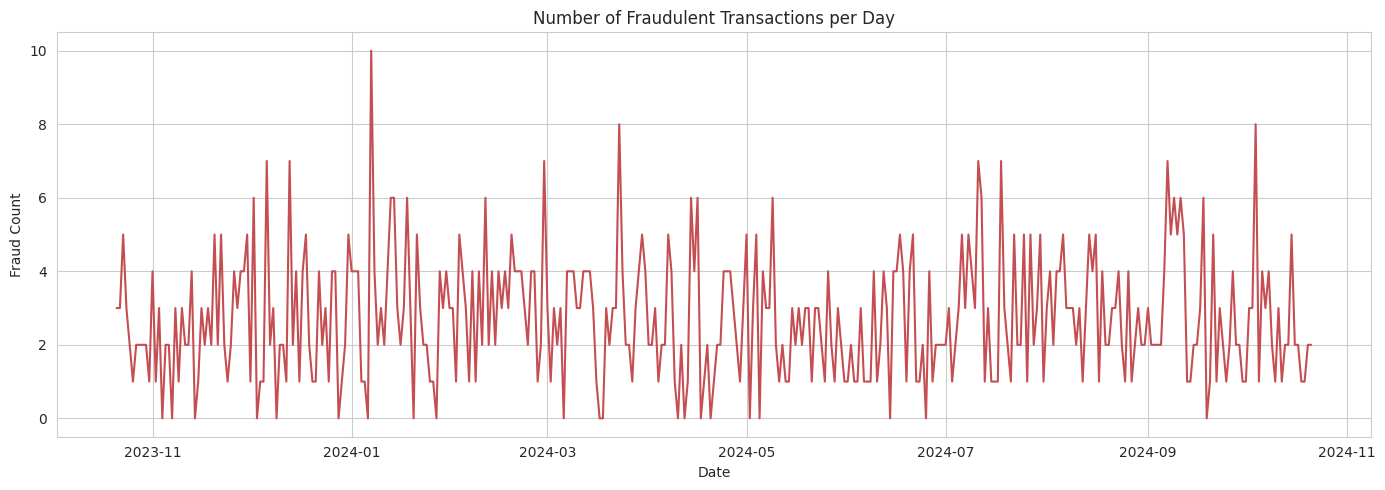

In [17]:
df['TransactionDay'] = df['TransactionDate'].dt.date
daily_fraud = df.groupby('TransactionDay')['IsFraud'].sum()

plt.figure(figsize=(14, 5))
daily_fraud.plot(color='#C44E52')
plt.title('Number of Fraudulent Transactions per Day')
plt.xlabel('Date')
plt.ylabel('Fraud Count')
plt.tight_layout()
plt.show()


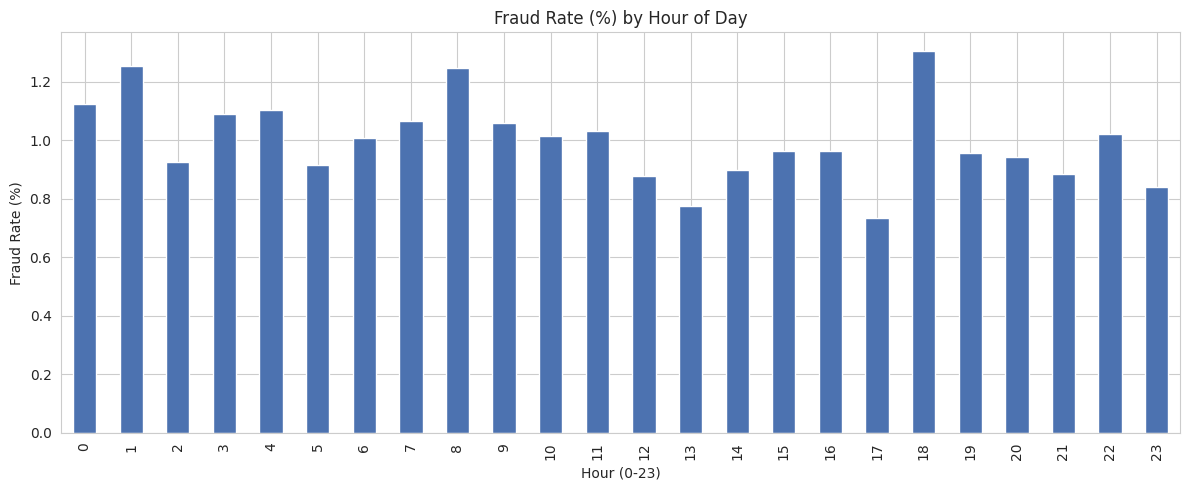

In [18]:
# Fraud by hour of day - do fraudsters prefer certain hours (e.g. late night)?
df['Hour'] = df['TransactionDate'].dt.hour
fraud_rate_by_hour = df.groupby('Hour')['IsFraud'].mean() * 100

plt.figure(figsize=(12, 5))
fraud_rate_by_hour.plot(kind='bar', color='#4C72B0')
plt.title('Fraud Rate (%) by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()


### 5.5 Correlation Between Numeric Features
A quick correlation heatmap helps us see if `Amount` or `MerchantID` are linearly
related to `IsFraud`. (Note: correlation only captures *linear* relationships —
it's normal for these values to look small even if a feature is still useful.)


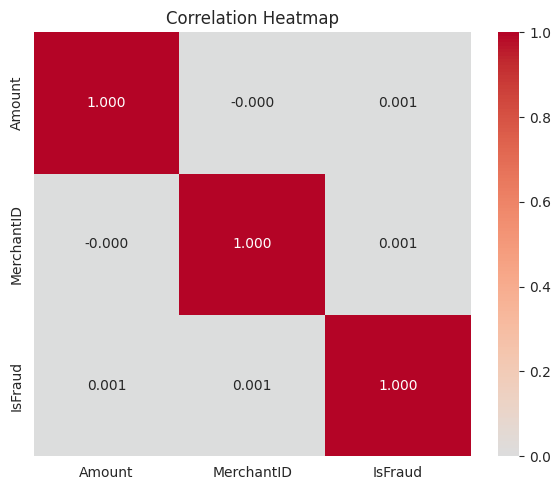

In [19]:
numeric_cols = ['Amount', 'MerchantID', 'IsFraud']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 6. Feature Engineering

Machine learning models need numbers, not text. We'll convert categorical
columns (`TransactionType`, `Location`) into numeric form, and pull out useful
pieces of information from the date column.

**New features we'll create:**
- `Hour` — hour of day (already created above)
- `DayOfWeek` — 0 = Monday ... 6 = Sunday
- `TransactionType_encoded` — 0/1 for purchase/refund
- `Location_encoded` — a number for each city


In [20]:
# Day of week feature
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek

# Encode categorical columns
le_type = LabelEncoder()
df['TransactionType_encoded'] = le_type.fit_transform(df['TransactionType'])

le_location = LabelEncoder()
df['Location_encoded'] = le_location.fit_transform(df['Location'])

print("TransactionType mapping:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))
print("Location mapping:", dict(zip(le_location.classes_, le_location.transform(le_location.classes_))))

df[['Amount', 'Hour', 'DayOfWeek', 'TransactionType_encoded', 'Location_encoded', 'IsFraud']].head()


TransactionType mapping: {'purchase': np.int64(0), 'refund': np.int64(1)}
Location mapping: {'Chicago': np.int64(0), 'Dallas': np.int64(1), 'Houston': np.int64(2), 'Los Angeles': np.int64(3), 'New York': np.int64(4), 'Philadelphia': np.int64(5), 'Phoenix': np.int64(6), 'San Antonio': np.int64(7), 'San Diego': np.int64(8), 'San Jose': np.int64(9)}


,Amount,Hour,DayOfWeek,TransactionType_encoded,Location_encoded,IsFraud
0,4189.27,14,2,1,7,0
1,2659.71,13,1,1,1,0
2,784.00,10,0,0,4,0
3,3514.40,23,5,0,5,0
4,369.07,18,4,0,6,0


## 7. Pattern Recognition with Clustering (K-Means)

Clustering is an **unsupervised** technique — it groups similar transactions
together *without* being told which ones are fraud. This helps us spot unusual
clusters that might contain a higher share of fraud, purely from the data's
natural structure.

We'll use **K-Means** on scaled numeric features, then check the fraud rate
inside each cluster.


In [21]:
# Features used for clustering
cluster_features = ['Amount', 'Hour', 'DayOfWeek', 'TransactionType_encoded', 'Location_encoded']
X_cluster = df[cluster_features].copy()

# Scale features so no single feature (like Amount) dominates due to its scale
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Try K-Means with 4 clusters (you can experiment with this number)
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster_scaled)

print("Number of transactions per cluster:")
print(df['Cluster'].value_counts().sort_index())


Number of transactions per cluster:
Cluster
0    25008
1    24857
2    25012
3    25123
Name: count, dtype: int64


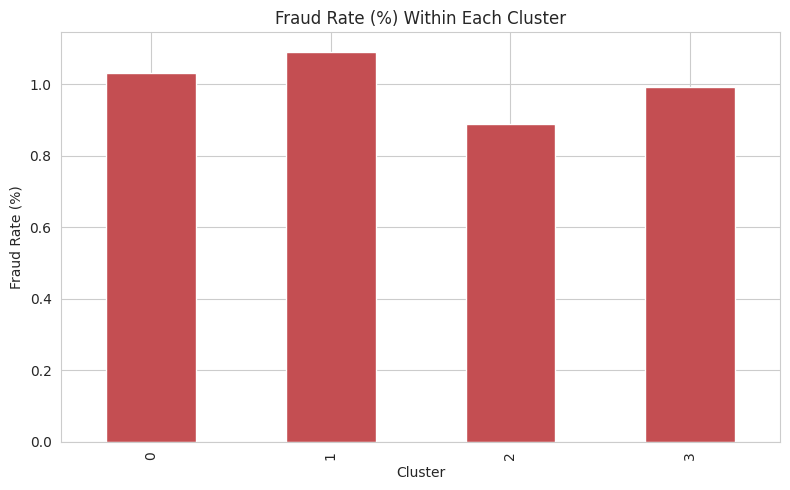

Cluster
0    1.032
1    1.090
2    0.888
3    0.991
Name: IsFraud, dtype: float64


In [22]:
# Fraud rate inside each cluster - do any clusters stand out?
cluster_fraud_rate = df.groupby('Cluster')['IsFraud'].mean() * 100

plt.figure(figsize=(8, 5))
cluster_fraud_rate.plot(kind='bar', color='#C44E52')
plt.title('Fraud Rate (%) Within Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

print(cluster_fraud_rate.round(3))


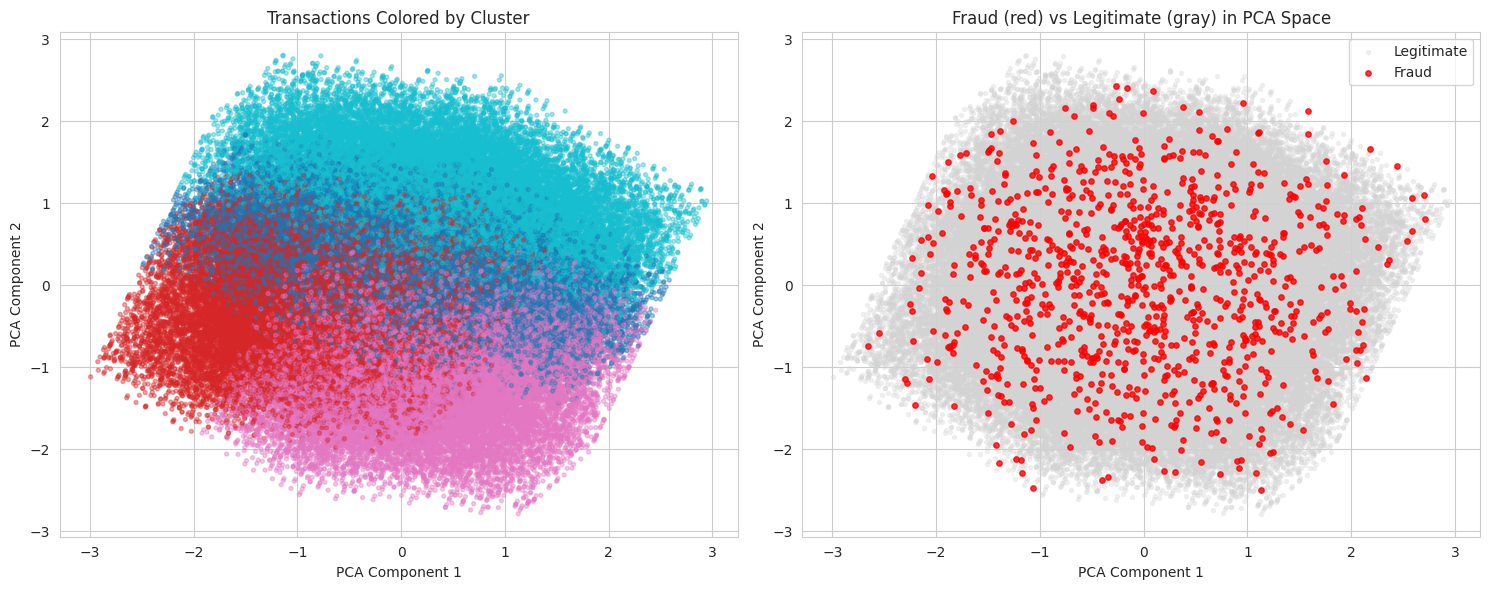

In [23]:
# Visualize clusters in 2D using PCA (Principal Component Analysis)
# PCA compresses our 5 features into 2 dimensions just so we can plot them
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = ax[0].scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], cmap='tab10', alpha=0.4, s=8)
ax[0].set_title('Transactions Colored by Cluster')
ax[0].set_xlabel('PCA Component 1')
ax[0].set_ylabel('PCA Component 2')

# Plot fraud points on top so they stand out
legit = df[df['IsFraud'] == 0]
fraud = df[df['IsFraud'] == 1]
ax[1].scatter(legit['PCA1'], legit['PCA2'], c='lightgray', alpha=0.3, s=8, label='Legitimate')
ax[1].scatter(fraud['PCA1'], fraud['PCA2'], c='red', alpha=0.8, s=15, label='Fraud')
ax[1].set_title('Fraud (red) vs Legitimate (gray) in PCA Space')
ax[1].set_xlabel('PCA Component 1')
ax[1].set_ylabel('PCA Component 2')
ax[1].legend()

plt.tight_layout()
plt.show()


**How to read this:** if fraud (red) were concentrated tightly in one area of
the right-hand chart, that would mean fraud has a very distinct "signature" our
features can capture. If it's spread out (as is common in tricky, well-simulated
data), it tells us fraud detection will need more subtle patterns than simple
clustering — which is exactly why we go on to build supervised models next.


## 8. Fraud Detection Modeling (Supervised Learning)

Now for the main event: training models that learn from **labeled** examples
(transactions we already know are fraud or not) to predict fraud on new,
unseen transactions.

### 8.1 Prepare the Data

We split our data into:
- **Features (X):** everything the model is allowed to look at
- **Target (y):** the answer we want it to predict (`IsFraud`)

Then we split into a **training set** (80%) to teach the model, and a
**test set** (20%) to fairly evaluate it on data it has never seen.

We use `stratify=y` so that both sets keep the same (small) fraud percentage —
otherwise we might accidentally end up with almost no fraud examples in the test set.


In [24]:
feature_cols = ['Amount', 'Hour', 'DayOfWeek', 'TransactionType_encoded', 'Location_encoded']
X = df[feature_cols]
y = df['IsFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print("\nFraud % in training set:", round(y_train.mean() * 100, 3))
print("Fraud % in test set:    ", round(y_test.mean() * 100, 3))


Training set size: (80000, 5)
Test set size:     (20000, 5)

Fraud % in training set: 1.0
Fraud % in test set:     1.0


In [25]:
# Scale features (helps Logistic Regression converge faster & perform better)
scaler_model = StandardScaler()
X_train_scaled = scaler_model.fit_transform(X_train)
X_test_scaled = scaler_model.transform(X_test)


### 8.2 Handling Class Imbalance

Remember: fraud is only ~1% of the data. If we train a model normally, it may
just learn to always predict "not fraud" and still look "accurate." To fight
this, we set `class_weight='balanced'` in our models — this tells the model to
pay **more attention** to the rare fraud examples during training.


### 8.3 Train Three Models

We'll train and compare:
1. **Logistic Regression** — a simple, fast, interpretable baseline
2. **Decision Tree** — captures non-linear rules, easy to visualize
3. **Random Forest** — an ensemble of many decision trees, usually the strongest of the three


In [26]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE, max_depth=8),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_estimators=200, max_depth=10, n_jobs=-1)
}

trained_models = {}
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    predictions[name] = {'preds': preds, 'probs': probs}

print("\n✅ All models trained!")


Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

✅ All models trained!


## 9. Model Evaluation

### ⚠️ Why NOT to trust accuracy alone
Since fraud is only ~1% of transactions, a model that predicts "legitimate"
for *everything* would score ~99% accuracy — while being completely useless!
That's why for fraud detection we focus on:

- **Precision** — of all transactions we flagged as fraud, how many really were fraud? (avoids annoying customers with false alarms)
- **Recall** — of all the real fraud cases, how many did we catch? (avoids missing actual fraud)
- **F1-score** — the balance between precision and recall
- **ROC-AUC** — how well the model separates fraud from non-fraud overall


In [27]:
results = []

for name in models.keys():
    preds = predictions[name]['preds']
    probs = predictions[name]['probs']

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs)

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': auc
    })

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.5082,0.0080,0.39,0.0156,0.4564
Decision Tree,0.5972,0.0097,0.39,0.0190,0.4779
Random Forest,0.9473,0.0046,0.02,0.0075,0.4750


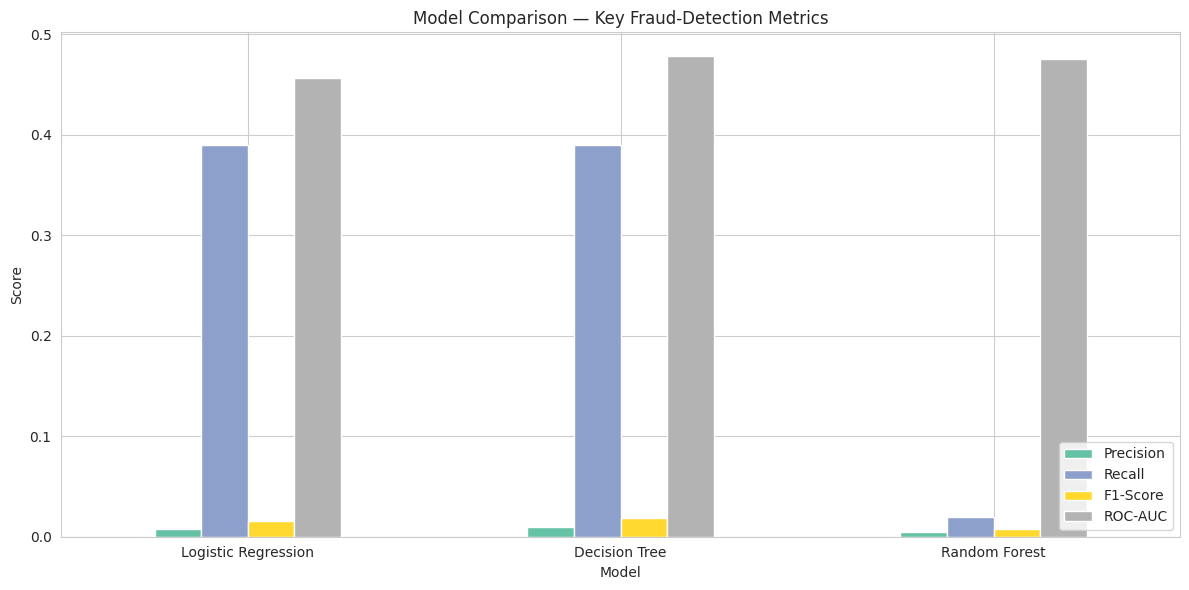

In [28]:
# Visual comparison of key metrics across models
results_df[['Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar', figsize=(12, 6), colormap='Set2'
)
plt.title('Model Comparison — Key Fraud-Detection Metrics')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 9.1 Confusion Matrices

A confusion matrix shows exactly *where* each model gets confused:
- **Top-left:** legitimate correctly identified
- **Bottom-right:** fraud correctly caught ✅
- **Top-right:** legitimate wrongly flagged as fraud (false alarm)
- **Bottom-left:** fraud missed entirely ❌ (the most costly mistake!)


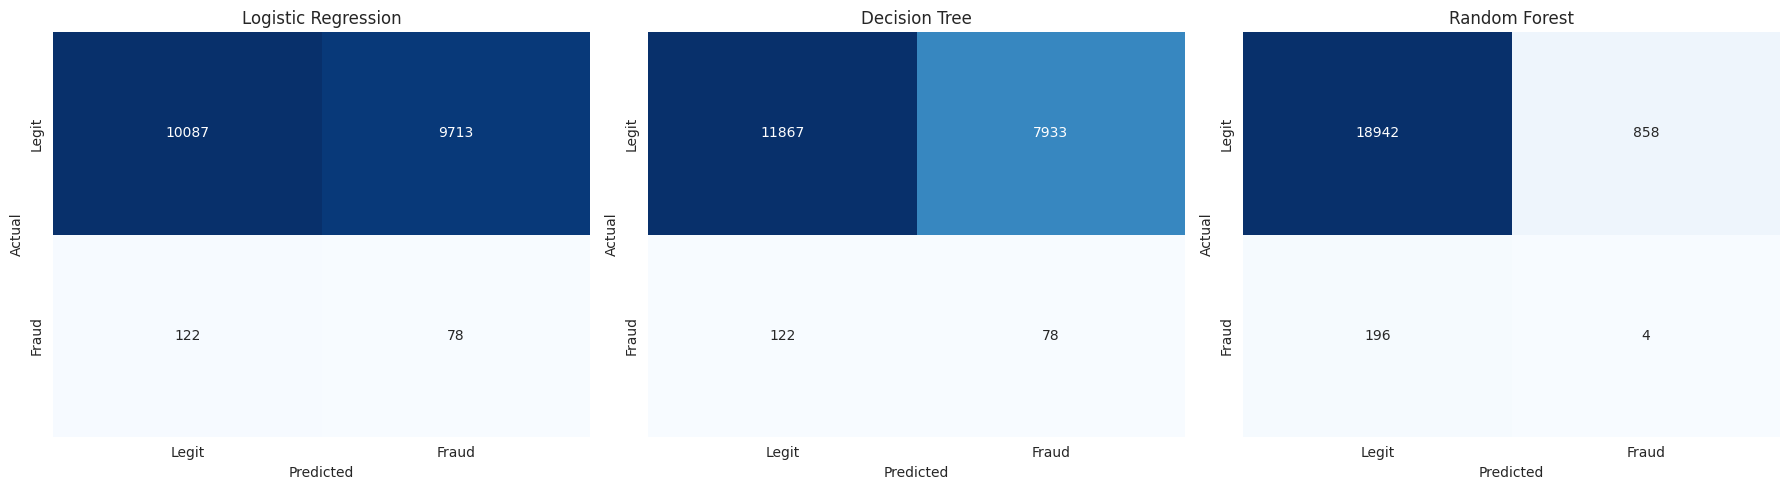

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions[name]['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


### 9.2 ROC Curves

The ROC curve plots the trade-off between catching fraud (True Positive Rate)
and false alarms (False Positive Rate) at every possible decision threshold.
A curve closer to the **top-left corner** is better; the diagonal dashed line
represents random guessing.


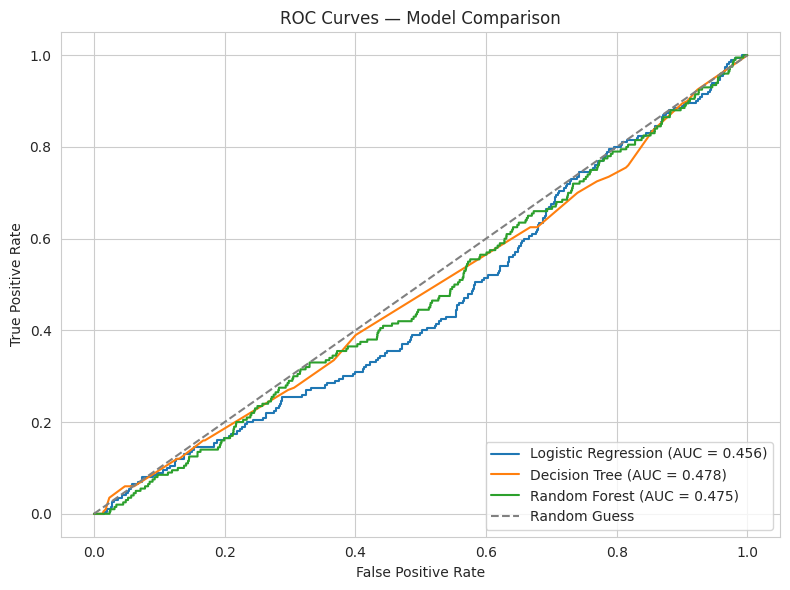

In [30]:
plt.figure(figsize=(8, 6))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, predictions[name]['probs'])
    auc_score = results_df.loc[name, 'ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [31]:
# Detailed classification report for the best-performing model (by F1-score)
best_model_name = results_df['F1-Score'].idxmax()
print(f"🏆 Best model by F1-Score: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name]['preds'],
                             target_names=['Legitimate', 'Fraud']))


🏆 Best model by F1-Score: Decision Tree

              precision    recall  f1-score   support

  Legitimate       0.99      0.60      0.75     19800
       Fraud       0.01      0.39      0.02       200

    accuracy                           0.60     20000
   macro avg       0.50      0.49      0.38     20000
weighted avg       0.98      0.60      0.74     20000



### 9.3 What Features Matter Most?

For our tree-based models, we can check which features they relied on most
to make decisions.


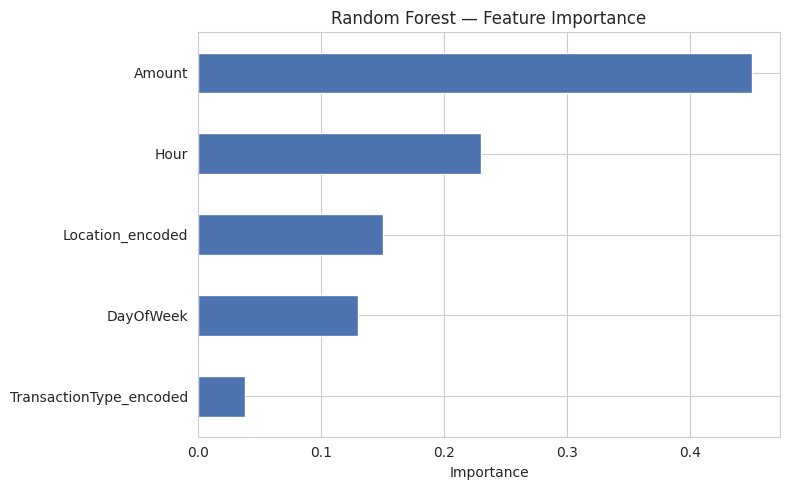

Amount                     0.450570
Hour                       0.230445
Location_encoded           0.150534
DayOfWeek                  0.130442
TransactionType_encoded    0.038009
dtype: float64


In [32]:
rf_model = trained_models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#4C72B0')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances)


## 10. Conclusions & Next Steps

### Summary of Findings
- The dataset is **highly imbalanced**: only about 1% of transactions are fraudulent, which is realistic but makes modeling harder.
- EDA showed how fraud rates vary by transaction type, location, and time — patterns worth monitoring in a real system.
- Clustering did not reveal a single obvious "fraud cluster," suggesting fraud in this data doesn't follow one simple pattern — supporting the need for supervised models.
- Among Logistic Regression, Decision Tree, and Random Forest, compare the printed metrics table above (Section 9) to see which model best balances **precision** and **recall** for your priorities.

### Ideas to Improve This Project Further
1. **Try more advanced imbalance techniques:** SMOTE (Synthetic Minority Oversampling), undersampling, or `imbalanced-learn` library.
2. **Try more algorithms:** XGBoost, LightGBM, or a simple Neural Network — often stronger than plain Random Forest.
3. **Add more features:** e.g., how unusual an amount is compared to that customer's/merchant's usual spending, transaction velocity (transactions per hour for a merchant), etc.
4. **Tune hyperparameters:** use `GridSearchCV` or `RandomizedSearchCV` to find the best settings for each model.
5. **Threshold tuning:** instead of the default 0.5 probability cutoff, adjust the decision threshold to prioritize catching more fraud (higher recall) or reducing false alarms (higher precision), depending on business needs.
6. **Deploy:** wrap the best model in a simple API (e.g., with Flask/FastAPI) so it can score transactions in real time.

---
🎉 **Congratulations!** You've completed a full data science pipeline — from raw
data to a working, evaluated fraud detection model.
